# Debug Seed Generation On One Slice

这个 notebook 用来调试一张 2D 切片经过 `get_seg(...)` 后，是否能产生合理的 seed。

它包含两种 seed 可视化：

- `2D component centroids`：直接对当前切片的连通域取质心
- `3D-style seeds from one-slice init_seg`：把当前切片嵌回 3D 体，再调用 `get_seeds_from_init_seg(...)`

第二种更接近现有代码里的真实 seed 提取方式，但这里只是单切片调试版，不是完整三轴 `init_seg` 流程。

In [410]:
import os
from typing import List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import skimage.measure

from vessel_model.data_manager import VolumeManager
from vessel_model.preprocessing import get_seg, get_seeds_from_init_seg

In [411]:
# ===== User Config =====
# 支持 .h5 / .nii / .nii.gz
volume_path = "/home/jiangshuai/code/XMem/data/allmouse_half/shared_chunk_cache/chunk_size_512/chunk_0000_z0_512_y0_512_x0_512/chunk_0000_z0_512_y0_512_x0_512_volume.nii.gz"
volume_path = "/home/jiangshuai/code/XMem/data/allmouse_half/shared_chunk_cache/chunk_size_512/chunk_0037_z512_1024_y1024_1536_x512_1024/chunk_0037_z512_1024_y1024_1536_x512_1024_volume.nii.gz"
volume_path = "/home/jiangshuai/code/XMem/data/allmouse/shared_chunk_cache/chunk_size_512/chunk_0012_z0_512_y512_1024_x512_1024/chunk_0012_z0_512_y512_1024_x512_1024_volume.nii.gz"
volume_path = "/data2/jiangshuai/data/BvEM/human_patch3.nii.gz"
dataset_key = "main"

# axis: 0=Z, 1=Y, 2=X
axis = 2
slice_index = 208
slice_index = 213

# get_seg(...) 参数
remove_portion = 0.98
gaussian_kernel = 30
min_bright = 40

# 注意：完整 multi-axis init_seg 默认是 min_size=10
# 如果你想更贴近单轴 get_seg 默认行为，可以改成 5
min_size = 1

figsize = (8, 8)
seed_marker_size = 80

In [412]:
def extract_axis_slice(volume: np.ndarray, axis: int, slice_index: int) -> np.ndarray:
    if axis == 0:
        return volume[slice_index, :, :]
    if axis == 1:
        return volume[:, slice_index, :]
    if axis == 2:
        return volume[:, :, slice_index]
    raise ValueError(f"axis must be 0/1/2, got {axis}")


def sample_2d_component_centroids(seg_mask: np.ndarray) -> List[Tuple[int, int]]:
    labeled = skimage.measure.label(seg_mask > 0)
    props = skimage.measure.regionprops(labeled)
    pts = []
    for prop in props:
        cy, cx = prop.centroid
        pts.append((int(round(cy)), int(round(cx))))
    return pts


def build_single_slice_init_seg(volume_shape: Tuple[int, int, int], axis: int, slice_index: int, seg_mask: np.ndarray) -> np.ndarray:
    init_seg = np.zeros(volume_shape, dtype=np.uint8)
    binary = (seg_mask > 0).astype(np.uint8)
    if axis == 0:
        init_seg[slice_index, :, :] = binary
    elif axis == 1:
        init_seg[:, slice_index, :] = binary
    else:
        init_seg[:, :, slice_index] = binary
    return init_seg


def project_global_seed_to_slice(seed: Tuple[int, int, int], axis: int) -> Tuple[int, int]:
    z, y, x = seed
    if axis == 0:
        return int(y), int(x)
    if axis == 1:
        return int(z), int(x)
    return int(z), int(y)


def show_points(ax, points, color: str, label: str, marker: str = "x"):
    if len(points) == 0:
        return
    ys = [p[0] for p in points]
    xs = [p[1] for p in points]
    ax.scatter(xs, ys, s=seed_marker_size, c=color, marker=marker, label=label)
    for i, (yy, xx) in enumerate(points):
        ax.text(xx + 2, yy + 2, str(i), color=color, fontsize=9)


In [413]:
assert os.path.exists(volume_path), f"File not found: {volume_path}"

vol_man = VolumeManager(volume_path, key=dataset_key)
volume = vol_man.vol

axis_name = {0: 'Z', 1: 'Y', 2: 'X'}[axis]
max_index = volume.shape[axis] - 1
assert 0 <= slice_index <= max_index, f"slice_index must be in [0, {max_index}]"

print(f"Loaded volume: {volume_path}")
print(f"Volume shape (z, y, x): {volume.shape}")
print(f"Viewing axis {axis} ({axis_name}), slice {slice_index}")

self.need_transpose: False
Loaded volume: /data2/jiangshuai/data/BvEM/human_patch3.nii.gz
Volume shape (z, y, x): (512, 512, 661)
Viewing axis 2 (X), slice 213


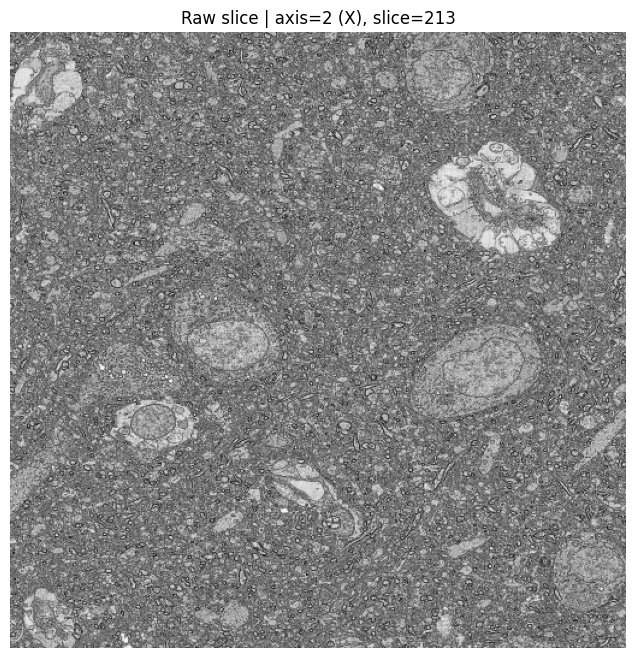

Slice shape: (512, 512)
Slice min/max: 45 / 255


In [414]:
slice_img = extract_axis_slice(volume, axis, slice_index)

plt.figure(figsize=figsize)
plt.imshow(slice_img, cmap='gray')
plt.title(f'Raw slice | axis={axis} ({axis_name}), slice={slice_index}')
plt.axis('off')
plt.show()

print(f"Slice shape: {slice_img.shape}")
print(f"Slice min/max: {slice_img.min()} / {slice_img.max()}")

In [415]:
seg_labeled = get_seg(
    slice_img,
    remove_portion=remove_portion,
    min_size=min_size,
    gaussian_kernel=gaussian_kernel,
    min_bright=min_bright,
)
seg_mask = (seg_labeled > 0).astype(np.uint8)

slice_seed_points_2d = sample_2d_component_centroids(seg_mask)

single_slice_init_seg = build_single_slice_init_seg(volume.shape, axis, slice_index, seg_mask)
global_seed_points_3d = get_seeds_from_init_seg(single_slice_init_seg)
global_seed_points_2d = [project_global_seed_to_slice(seed, axis) for seed in global_seed_points_3d]

print(f"2D seg foreground pixels: {int(seg_mask.sum())}")
print(f"2D component-centroid seeds: {len(slice_seed_points_2d)}")
print(f"3D-style seeds from one-slice init_seg: {len(global_seed_points_3d)}")
print("3D-style global seeds:", global_seed_points_3d)

Extracting seeds from Init Seg...
Extracted 1 component centroids (before distance filter).
Filtering 1 seeds with min_dist=5.0...
  -> 1 seeds remaining.
2D seg foreground pixels: 89
2D component-centroid seeds: 1
3D-style seeds from one-slice init_seg: 1
3D-style global seeds: [(38, 9, 213)]


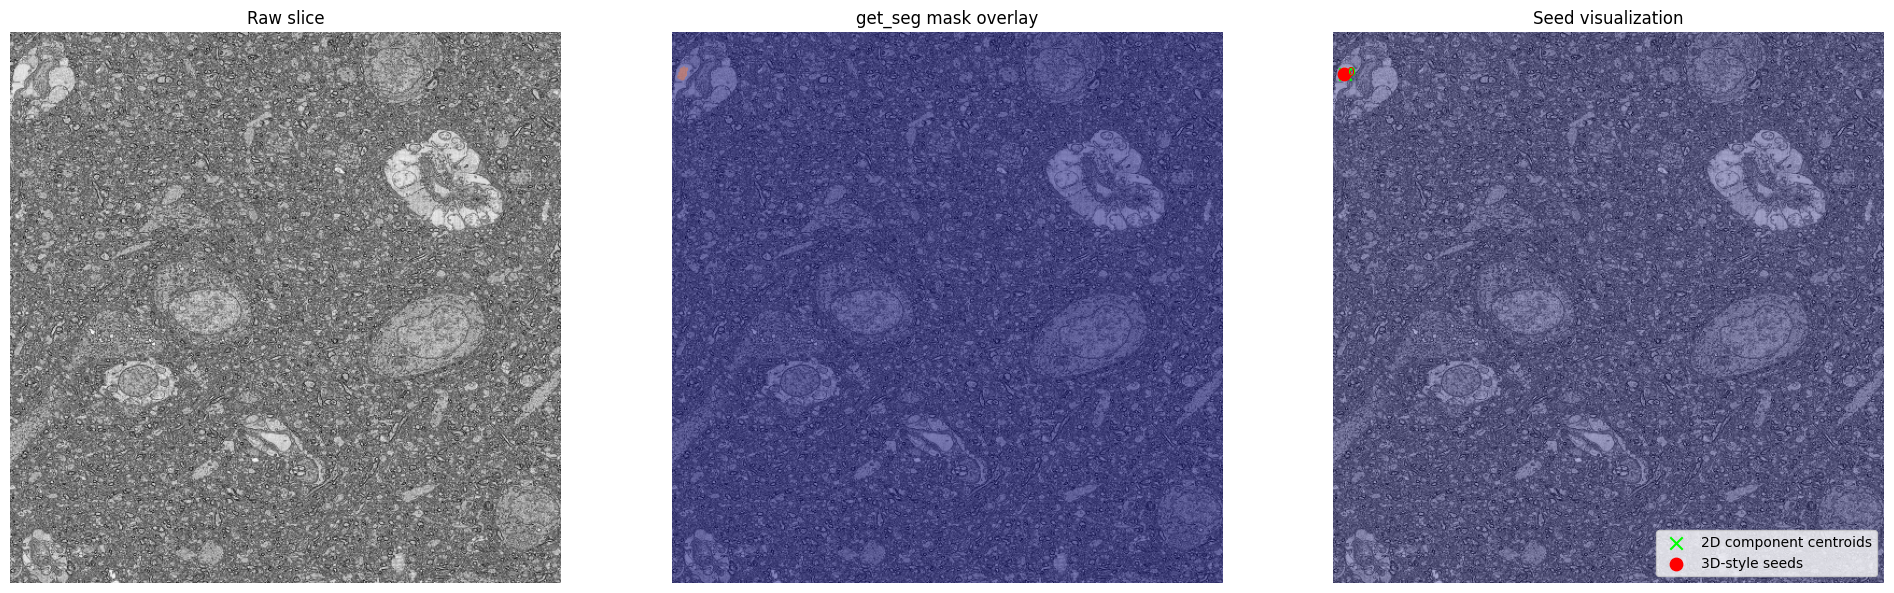

In [416]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].imshow(slice_img, cmap='gray')
axes[0].set_title('Raw slice')
axes[0].axis('off')

axes[1].imshow(slice_img, cmap='gray')
axes[1].imshow(seg_mask, cmap='jet', alpha=0.45)
axes[1].set_title('get_seg mask overlay')
axes[1].axis('off')

axes[2].imshow(slice_img, cmap='gray')
axes[2].imshow(seg_mask, cmap='jet', alpha=0.30)
show_points(axes[2], slice_seed_points_2d, color='lime', label='2D component centroids', marker='x')
show_points(axes[2], global_seed_points_2d, color='red', label='3D-style seeds', marker='o')
axes[2].set_title('Seed visualization')
axes[2].axis('off')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [417]:
props = skimage.measure.regionprops(skimage.measure.label(seg_mask > 0))
component_table = []
for i, prop in enumerate(props):
    cy, cx = prop.centroid
    component_table.append(
        {
            'component_id': i,
            'area': int(prop.area),
            'centroid_y': float(cy),
            'centroid_x': float(cx),
            'bbox': tuple(int(v) for v in prop.bbox),
        }
    )

component_table

[{'component_id': 0,
  'area': 89,
  'centroid_y': 38.01123595505618,
  'centroid_x': 9.51685393258427,
  'bbox': (32, 5, 45, 15)}]